In [1]:
import netCDF4
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime, timedelta
from tqdm import tqdm
from shapely.geometry import Point
from scipy.stats import skew, kurtosis, entropy
from scipy.fft import fft
from sklearn.preprocessing import MinMaxScaler
import os
#from pycaret.classification import setup, compare_models, tune_model, finalize_model, save_model, plot_model, evaluate_model, dashboard, save_experiment, blend_models, get_config
import pyarrow as pa
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from numpy import full
import scipy as sp
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


import numpy as np
from scipy.stats import skew, kurtosis, entropy
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.decomposition import PCA
from collections import defaultdict
import cv2
from scipy.ndimage import center_of_mass, distance_transform_edt
from skimage.measure import regionprops
from skimage.feature import graycomatrix, graycoprops
import warnings

import numpy as np
from scipy import ndimage
from sklearn.cluster import DBSCAN
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [2]:
ROOT_DIR =  "./sample_data/" #E:/data/RONGOWAI_L1_SDR_V1.0/' # Change this to your root directory

In [3]:
class SurfaceTypeUtils:
    surface_type_dict = {
        -1: "Ocean",
        0: "NaN",
        1: "Artifical",
        2: "Barely vegetated",
        3: "Inland water",
        4: "Crop",
        5: "Grass",
        6: "Shrub",
        7: "Forest"
    }
    ddm_antennas = {
        0: 'None',
        1: 'Zenith',
        2: 'LHCP',
        3: 'RHCP',
    }

In [4]:
class GeoUtils:
    def __init__(self, world_shapefile_path):
        self.world = gpd.read_file(world_shapefile_path)

    @staticmethod
    def add_seconds(time, seconds):
        timestamp = datetime.strptime(time, "%Y-%m-%d %H:%M:%S")
        new_timestamp = timestamp + timedelta(seconds=seconds)
        return new_timestamp.strftime("%Y-%m-%d %H:%M:%S")

    def is_land(self, lat, lon):
        point = Point(lon, lat)
        return any(self.world.contains(point))

    @staticmethod
    def check_ocean_and_land(lst):
        has_ocean = -1 in lst
        has_land = any(1 <= num <= 7 for num in lst)
        return has_ocean and has_land

    @staticmethod
    def fill_and_filter(arr):
        mask_all_nan = np.all(np.isnan(arr), axis=(2, 3))
        arr_filled = arr.copy()
        for i in range(arr.shape[0]):
            nan_indices = np.where(mask_all_nan[i])[0]
            if len(nan_indices) > 0:
                valid_indices = np.where(~mask_all_nan[i])[0]
                if len(valid_indices) > 0:
                    mean_matrix = np.nanmean(arr[i, valid_indices, :, :], axis=0)
                    arr_filled[i, nan_indices, :, :] = mean_matrix
        mask_discard = np.all(mask_all_nan, axis=1)
        arr_filtered = arr_filled[~mask_discard]
        return arr_filtered, list(np.where(mask_discard.astype(int) == 1)[0])


In [5]:
class NetCDFPreprocessor:
    def __init__(self, root_dir, preprocessing_method=str):
        self.root_dir = root_dir
        self.netcdf_file_list = os.listdir(root_dir)
        self.preprocessing_method = preprocessing_method
        if self.preprocessing_method not in ['filtered', 'with_lat_lons', 'unfiltered']:
            raise ValueError("Invalid preprocessing method. Choose from 'filtered', 'with_lat_lons', or 'unfiltered'.")

    @staticmethod
    def check_integrity(f):
        """Check integrity of the netCDF file"""
        if not isinstance(f, netCDF4.Dataset):
            raise ValueError("Input must be a netCDF4.Dataset object")
        if 'raw_counts' not in f.variables:
            raise KeyError("The netCDF file does not contain 'raw_counts' variable")
        if 'sp_alt' not in f.variables or 'sp_inc_angle' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_alt' or 'sp_inc_angle' variables")
        if 'sp_rx_gain_copol' not in f.variables or 'sp_rx_gain_xpol' not in f.variables or 'ddm_snr' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_rx_gain_copol', 'sp_rx_gain_xpol' or 'ddm_snr' variables")
        if 'sp_lat' not in f.variables or 'sp_lon' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_lat' or 'sp_lon' variables")
        if 'sp_surface_type' not in f.variables:
            raise KeyError("The netCDF file does not contain 'sp_surface_type' variable")
        if 'ac_alt' not in f.variables:
            raise KeyError("The netCDF file does not contain 'ac_alt' variable")
        if f.variables['raw_counts'].ndim != 4:
            raise ValueError("The 'raw_counts' variable must have 4 dimensions")

    def preprocess_snr_filtered(self, f):
        """ Preprocess the netCDF file and return fit data, labels and specular point centers with filtering on signal-to-noise ratio """
        # Check integrity of the netCDF file
        self.check_integrity(f)

        raw_counts = f.variables['raw_counts'][:]
        ac_alt = f.variables['ac_alt'][:]
        sp_alt = f.variables['sp_alt'][:]
        copol = f.variables['sp_rx_gain_copol'][:]
        xpol = f.variables['sp_rx_gain_xpol'][:]
        snr = f.variables['ddm_snr'][:]
        sp_inc_angle = f.variables['sp_inc_angle'][:]
        sp_center_bin_delay_row = f.variables['brcs_ddm_peak_bin_delay_row'][:]
        sp_center_bin_delay_col = f.variables['brcs_ddm_peak_bin_dopp_col'][:]

        distance_2d = (ac_alt[:, np.newaxis] - sp_alt) / np.cos(np.deg2rad(sp_inc_angle)) # Distance between the aircraft and the specular point

        # Filtering mask
        keep_mask = (
            (copol >= 5) & # # SP copolarized gain
            (xpol >= 5) & # SP cross-polarized gain
            (snr > 0) & # Positive signal-to-Noise Ratio
            (distance_2d >= 2000) & #SP distance min
            (distance_2d <= 10000) & #SP distance max
            ~np.isnan(copol) & 
            ~np.isnan(xpol) & 
            ~np.isnan(snr) & 
            ~np.isnan(distance_2d)
        )

        aux_row_counts = np.full(raw_counts.shape, np.nan, dtype=np.float32)
        aux_array_sp_row = np.full(sp_center_bin_delay_row.shape, np.nan, dtype=np.float32)
        aux_array_sp_col = np.full(sp_center_bin_delay_col.shape, np.nan, dtype=np.float32)
        
        i_indices, j_indices = np.where(keep_mask)
        aux_row_counts[i_indices, j_indices] = raw_counts[i_indices, j_indices]
        aux_array_sp_row[i_indices, j_indices] = sp_center_bin_delay_row[i_indices, j_indices]
        aux_array_sp_col[i_indices, j_indices] = sp_center_bin_delay_col[i_indices, j_indices]

        assert aux_row_counts.shape[0] == aux_array_sp_row.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_row arrays"
        assert aux_row_counts.shape[0] == aux_array_sp_col.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_col arrays"

        n_time, n_samples = raw_counts.shape[:2]
        aux_raw_counts_reshaped = aux_row_counts.reshape(n_time * n_samples, *raw_counts.shape[2:])
        aux_array_sp_row_reshaped = aux_array_sp_row.reshape(n_time * n_samples, *aux_array_sp_row.shape[2:])
        aux_array_sp_col_reshaped = aux_array_sp_col.reshape(n_time * n_samples, *aux_array_sp_col.shape[2:])

        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_row_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_row_reshaped arrays after reshaping"
        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_col_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_col_reshaped arrays after reshaping"
        #freeing memory
        del aux_row_counts
        del aux_array_sp_row
        del aux_array_sp_col

        # Filter out NaN and zero-sum rows
        valid_mask = ~np.any(np.isnan(aux_raw_counts_reshaped), axis=(1, 2)) & (np.sum(aux_raw_counts_reshaped, axis=(1, 2)) > 0)

        sp_center_bin_delay_row_filtered = aux_array_sp_row_reshaped[valid_mask]
        sp_center_bin_delay_col_filtered = aux_array_sp_col_reshaped[valid_mask]
        sp_centers_filtered = list(zip(sp_center_bin_delay_row_filtered.flatten(), sp_center_bin_delay_col_filtered.flatten()))

        fit_data = aux_raw_counts_reshaped[valid_mask].reshape(valid_mask.sum(), -1)

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"


        surface_types = np.nan_to_num(f.variables["sp_surface_type"][:], nan=0).ravel()
        label_data = np.isin(surface_types, np.arange(1, 8)).astype(np.int32)
        label_data = label_data[valid_mask]
        
        # Ensure that fit_data and label_data have the same length
        assert fit_data.shape[0] == len(label_data), \
            f"Shape mismatch: fit_data {fit_data.shape[0]}, label_data {len(label_data)}"

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"

        return fit_data, label_data, sp_centers_filtered

    """def preprocess_w_lat_lons(self, f):
        # Version of the preprocessing function returning latitude and longitudes of the specular points

        self.check_integrity(f)
        raw_counts = np.array(f.variables['raw_counts'])

        # Distance between the aircraft and the specular point
        ac_alt_2d = np.repeat(np.array(f.variables['ac_alt'])[:, np.newaxis], 20, axis=1)
        distance_2d = (ac_alt_2d - f.variables['sp_alt'][:]) / np.cos(np.deg2rad(f.variables['sp_inc_angle'][:]))

        copol = f.variables['sp_rx_gain_copol'][:]
        xpol = f.variables['sp_rx_gain_xpol'][:]
        snr = f.variables['ddm_snr'][:]
        dist = distance_2d[:]
        specular_point_lat = f.variables['sp_lat'][:]
        specular_point_lon = f.variables['sp_lon'][:]

        # Filtering with mask
        keep_mask = (copol >= 5) & (xpol >= 5) & (snr > 0) & ((dist >= 2000) & (dist <= 10000)) & (~np.isnan(copol.data) & ~np.isnan(xpol.data) & ~np.isnan(snr.data) & ~np.isnan(dist.data) & ~np.isnan(specular_point_lat.data) & ~np.isnan(specular_point_lon.data))
        to_keep_indices = np.argwhere(keep_mask)

        filtered_raw_counts = [raw_counts[i, j] for i, j in to_keep_indices]
        aux_row_counts = np.full(raw_counts.shape, np.nan, dtype=np.float32)

        specular_point_lats = specular_point_lat[to_keep_indices[:, 0]]
        specular_point_lons = specular_point_lon[to_keep_indices[:, 0]]

        for idx, (i, j) in enumerate(to_keep_indices):
            aux_row_counts[i, j] = filtered_raw_counts[idx]
        # Reshape the output array to match the original dimensions
            raw_counts_filtered = aux_row_counts.copy()

        raw_counts_filtered = aux_row_counts.copy()
        del aux_row_counts

        ddm_data_dict = {
            'Raw_Counts': raw_counts_filtered.reshape(raw_counts_filtered.shape[0]*raw_counts_filtered.shape[1], raw_counts_filtered.shape[2], raw_counts_filtered.shape[3]),
        }
        keep_indices = np.where(
            np.all(~np.isnan(ddm_data_dict['Raw_Counts']), axis=(1, 2)) & (np.sum(ddm_data_dict['Raw_Counts'], axis=(1, 2)) > 0)
        )[0]
        fit_data = np.array([ddm_data_dict['Raw_Counts'][f].ravel() for f in keep_indices])

        specular_point_lats = specular_point_lat.ravel()[keep_indices]
        specular_point_lons = specular_point_lon.ravel()[keep_indices]

        surface_types = f.variables["sp_surface_type"][:]
        surface_types = np.nan_to_num(surface_types, nan=0)
        surface_types_unravelled = surface_types.ravel()
        label_data = [1 if surface_type in np.arange(1, 8) else 0 for surface_type in surface_types_unravelled]
        label_data = [label_data[lab] for lab in range(len(label_data)) if lab in keep_indices]

        assert np.array(fit_data).shape[0] == len(label_data) == np.array(specular_point_lats).shape[0] == np.array(specular_point_lons).shape[0], \
            f"Shape mismatch: fit_data {np.array(fit_data).shape[0]}, label_data {len(label_data)}, lats {np.array(specular_point_lats).shape[0]}, lons {np.array(specular_point_lons).shape[0]}"


        return fit_data, label_data, specular_point_lats, specular_point_lons"""

    def preprocess_snr_unfiltered(self, f):
        """ Preprocess the netCDF file and return fit data, labels and specular point centers without filtering on signal-to-noise ratio """
        # Check integrity of the netCDF file
        self.check_integrity(f)

        raw_counts = f.variables['raw_counts'][:]
        ac_alt = f.variables['ac_alt'][:]
        sp_alt = f.variables['sp_alt'][:]
        sp_inc_angle = f.variables['sp_inc_angle'][:]
        copol = f.variables['sp_rx_gain_copol'][:]
        xpol = f.variables['sp_rx_gain_xpol'][:]
        #snr = f.variables['ddm_snr'][:]
        sp_center_bin_delay_row = f.variables['brcs_ddm_peak_bin_delay_row'][:]
        sp_center_bin_delay_col = f.variables['brcs_ddm_peak_bin_dopp_col'][:]

        #Distance between the aircraft and the specular point
        distance_2d = (ac_alt[:, np.newaxis] - sp_alt) / np.cos(np.deg2rad(sp_inc_angle))
        # Filtering mask without SNR
        keep_mask = (
            (copol >= 5) & 
            (xpol >= 5) & 
        #   (snr > 0)  &
            (distance_2d >= 2000) & 
            (distance_2d <= 10000) &
            ~np.isnan(copol) & 
            ~np.isnan(xpol) & 
            #~np.isnan(snr) & 
            ~np.isnan(distance_2d)
        )
    
        aux_row_counts = np.full(raw_counts.shape, np.nan, dtype=np.float32)
        aux_array_sp_row = np.full(sp_center_bin_delay_row.shape, np.nan, dtype=np.float32)
        aux_array_sp_col = np.full(sp_center_bin_delay_col.shape, np.nan, dtype=np.float32)

        i_indices, j_indices = np.where(keep_mask)

        aux_row_counts[i_indices, j_indices] = raw_counts[i_indices, j_indices]
        aux_array_sp_row[i_indices, j_indices] = sp_center_bin_delay_row[i_indices, j_indices]
        aux_array_sp_col[i_indices, j_indices] = sp_center_bin_delay_col[i_indices, j_indices]

        assert aux_row_counts.shape[0] == aux_array_sp_row.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_row arrays"
        assert aux_row_counts.shape[0] == aux_array_sp_col.shape[0] , "First dimension mismatch among aux_row_counts and aux_array_sp_col arrays"

        n_time, n_samples = raw_counts.shape[:2]
        aux_raw_counts_reshaped = aux_row_counts.reshape(n_time * n_samples, *raw_counts.shape[2:])
        aux_array_sp_row_reshaped = aux_array_sp_row.reshape(n_time * n_samples, *aux_array_sp_row.shape[2:])
        aux_array_sp_col_reshaped = aux_array_sp_col.reshape(n_time * n_samples, *aux_array_sp_col.shape[2:])


        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_row_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_row_reshaped arrays after reshaping"
        assert aux_raw_counts_reshaped.shape[0] == aux_array_sp_col_reshaped.shape[0], "First dimension mismatch among aux_raw_counts_reshaped and aux_array_sp_col_reshaped arrays after reshaping"

        del aux_row_counts
        del aux_array_sp_row
        del aux_array_sp_col

        valid_mask = ~np.any(np.isnan(aux_raw_counts_reshaped), axis=(1, 2)) & (np.sum(aux_raw_counts_reshaped, axis=(1, 2)) > 0)

        sp_center_bin_delay_row_filtered = aux_array_sp_row_reshaped[valid_mask]
        sp_center_bin_delay_col_filtered = aux_array_sp_col_reshaped[valid_mask]
        sp_centers_filtered = list(zip(sp_center_bin_delay_row_filtered.flatten(), sp_center_bin_delay_col_filtered.flatten()))

        fit_data = aux_raw_counts_reshaped[valid_mask].reshape(valid_mask.sum(), -1)

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"
    
        surface_types = np.nan_to_num(f.variables["sp_surface_type"][:], nan=0).ravel()
        label_data = np.isin(surface_types, np.arange(1, 8)).astype(np.int32)
        label_data = label_data[valid_mask]
        # Ensure that fit_data and label_data have the same length
        assert fit_data.shape[0] == len(label_data), \
            f"Shape mismatch: fit_data {fit_data.shape[0]}, label_data {len(label_data)}"

        assert len(sp_centers_filtered) == fit_data.shape[0], "First dimension sp_centers_filtered and fit_data mismatch after reshaping"

        return fit_data, label_data, sp_centers_filtered


    def process_all_files_random_picked(self, chunk_size = int, sample_fraction = float, n_files_to_pick= int, remove_chunks= bool):
        """ Process all netCDF files in the directory, randomly picking a specified number of files,
        and save the processed data and labels in chunks."""

        full_data = []
        full_labels = []
        full_sp_centers = []
        counter = 0

        # Take a random number of netCDF files
        if int(len(self.netcdf_file_list)) > n_files_to_pick: # type: ignore
            np.random.seed(42)
            random_netcdf_selected_files = np.random.choice(self.netcdf_file_list, n_files_to_pick, replace=False) # type: ignore
            print(f'Selezionati {n_files_to_pick} file netCDF casuali dalla lista')
        else:
            random_netcdf_selected_files = self.netcdf_file_list

        for file_name in tqdm(random_netcdf_selected_files, desc="Processing files"):
            if not file_name.endswith('.nc'):
                continue
            try:
                f = netCDF4.Dataset(f'{self.root_dir}{file_name}')
                if self.preprocessing_method == 'unfiltered':
                    data, labels, sp_centers = self.preprocess_snr_unfiltered(f)
                    
                #elif self.preprocessing_method == 'with_lat_lons':
                #    data, labels, latitudes, longitudes = self.preprocess_w_lat_lons(f)
                else:
                    # Default to filtered preprocessing
                    data, labels, sp_centers = self.preprocess_snr_unfiltered(f)
                assert (len(data) == len(labels)), f"Data and labels length mismatch in file {file_name}: {len(data)} != {len(labels)}"
                full_data.append(data)
                full_labels.append(labels)
                full_sp_centers.append(sp_centers)
            except Exception as e:
                print(f"Error processing file {file_name}: {e}")
                continue
            counter += 1
            if counter == n_files_to_pick:
                break
        print(f"Processed {counter} files out of {len(random_netcdf_selected_files)} selected files.")

        # Filtering on data shape
        valid_indices = [i for i, arr in enumerate(full_data) if arr.ndim == 2 if arr.shape[1] == 200]
        full_data_clean = [full_data[i] for i in valid_indices]
        full_labels_clean = [full_labels[i] for i in valid_indices]
        full_sp_centers = [full_sp_centers[i] for i in valid_indices]

        assert len(full_sp_centers) == len(full_data_clean), "First dimension sp_centers and fit_data mismatch after reshaping"

        # Chunking
        os.makedirs('temp_data/binary_classification', exist_ok=True)

        full_data_sampled = []
        full_labels_sampled = []
        full_sp_centers_sampled = []

        num_chunks = int(np.ceil(len(full_data_clean) / chunk_size))  # type: ignore
        print(f"Total number of chunks: {num_chunks}")
        for idx in range(num_chunks):
            start = idx * chunk_size # type: ignore
            end = min((idx + 1) * chunk_size, len(full_data_clean)) # type: ignore
            chunk_data = np.vstack(full_data_clean[start:end])
            chunk_labels = np.hstack(full_labels_clean[start:end])
            chunk_sp_centers = np.vstack(full_sp_centers[start:end])

            if chunk_data.size == 0 or chunk_labels.size == 0:
                print(f"Skipping empty chunk {idx + 1}/{num_chunks}")
                continue
            print(f"Chunk {idx + 1}/{num_chunks} processed with shape {chunk_data.shape} and labels shape {chunk_labels.shape} and sp_centers shape {chunk_sp_centers.shape}")

            # Save each chunk to parquet files
            if chunk_data.shape[0] == 0 or chunk_labels.shape[0] == 0 or chunk_sp_centers.shape[0] == 0:
                print(f"Skipping empty chunk {idx + 1}/{num_chunks}")
                continue

            fit_data_df = pd.DataFrame(chunk_data)
            labels_df = pd.DataFrame(chunk_labels, columns=['label'])
            sp_centers_df = pd.DataFrame(chunk_sp_centers, columns=['delay', 'dopp'])

            table_fit = pa.Table.from_pandas(fit_data_df, preserve_index=False)
            table_labels = pa.Table.from_pandas(labels_df, preserve_index=False)
            table_sp_centers = pa.Table.from_pandas(sp_centers_df, preserve_index=False)

            pq.write_table(
                table_fit,
                f'temp_data/binary_classification/fit_data_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )
            pq.write_table(
                table_labels,
                f'temp_data/binary_classification/labels_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )
            pq.write_table(
                table_sp_centers,
                f'temp_data/binary_classification/sp_centers_chunk_{idx}.parquet',
                compression='zstd',
                use_dictionary=True,
            )

            _, X_sampled, _, y_sampled, _, sp_centers_sampled = train_test_split(
                chunk_data,
                chunk_labels,
                chunk_sp_centers,
                test_size=sample_fraction, # e.g., 0.1 for 10% sampling
                stratify=chunk_labels,
                random_state=42
            )
            print(f"Chunk {idx + 1}/{num_chunks} sampled to shape {X_sampled.shape} and labels shape {y_sampled.shape} and sp_centers shape {sp_centers_sampled.shape}")
            
            full_data_sampled.append(X_sampled)
            full_labels_sampled.append(y_sampled)
            full_sp_centers_sampled.append(sp_centers_sampled)

        del full_data, full_labels

        full_data_sampled_stratified = np.vstack(full_data_sampled)
        full_labels_sampled_stratified = np.hstack(full_labels_sampled)
        full_sp_centers_sampled_stratified = np.vstack(full_sp_centers_sampled)

        del full_data_sampled, full_labels_sampled, full_sp_centers_sampled
        print(f"Shape of sampled data after chunking and sampling: {np.array(full_data_sampled_stratified).shape}")
        print(f"Shape of sampled labels after chunking and sampling: {np.array(full_labels_sampled_stratified).shape}")
        print(f"Shape of sampled sp_centers after chunking and sampling: {np.array(full_sp_centers_sampled_stratified).shape}")

        # Save the final sampled data and labels in parquet format
        if not os.path.exists('temp_data/binary_classification'):
            print("Creating directory temp_data/binary_classification")
            os.makedirs('temp_data/binary_classification', exist_ok=True)

        # Save fit_data 
        fit_data_df = pd.DataFrame(full_data_sampled_stratified)
        table_fit = pa.Table.from_pandas(fit_data_df, preserve_index=False)
        pq.write_table(
            table_fit,
            'temp_data/binary_classification/fit_data_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Save labels
        labels_df = pd.DataFrame(full_labels_sampled_stratified, columns=['label'])
        table_labels = pa.Table.from_pandas(labels_df, preserve_index=False)
        pq.write_table(
            table_labels,
            'temp_data/binary_classification/labels_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Save sp_centers
        sp_centers_df = pd.DataFrame(full_sp_centers_sampled_stratified, columns=['delay', 'dopp'])
        table_sp_centers = pa.Table.from_pandas(sp_centers_df, preserve_index=False)
        pq.write_table(
            table_sp_centers,
            'temp_data/binary_classification/sp_centers_binary_test.parquet',
            compression='zstd',
            use_dictionary=True,
        )
        # Clean up
        del fit_data_df, labels_df, table_fit, table_labels, sp_centers_df, table_sp_centers

        print("Data and labels saved in temp_data/binary_classification directory.")
        # Remove all chunk parquet files if flag is set (to save space)
        if remove_chunks:
            try:
                chunk_dir = 'temp_data/binary_classification'
                for fname in os.listdir(chunk_dir):
                    if fname.startswith('fit_data_chunk_') or fname.startswith('labels_chunk_') or fname.startswith('sp_centers_chunk_'):
                        os.remove(os.path.join(chunk_dir, fname))
                print("All chunk files removed.")
            except Exception as e:
                print(f"Error removing chunk files: {e}")

        return full_data_sampled_stratified, full_labels_sampled_stratified, full_sp_centers_sampled_stratified



In [6]:
class PeakRegionDetector:
    """
    Classe per trovare regioni di picco in immagini 5x40.
    """
    def __init__(self, N=10, method='statistical'):
        """
        Inizializza il detector.
        
        Parameters:
        -----------
        N : int, default=10
            Numero massimo di pixel nella regione
        method : str, default='statistical'
            Metodo da usare: 'statistical', 'adaptive', 'clustering'
        """
        self.N = N
        self.method = method
        self._validate_method()
    
    def _validate_method(self):
        """Valida il metodo selezionato"""
        valid_methods = ['statistical', 'adaptive', 'clustering']
        if self.method not in valid_methods:
            raise ValueError(f"Method deve essere uno tra: {valid_methods}")
    
    def find_peak_region(self, ddm):
        """
        Trova una regione di picco in un'immagine 5x40.
        
        Parameters:
        -----------
        ddm : array_like, shape (200,)
            Array 1D da reshapare in (40, 5)
        
        Returns:
        --------
        pixels : list of tuples
            Lista di coordinate (row, col) dei pixel nella regione
        centroid : tuple
            Coordinata (row, col) del centroide della regione
        """
        # Reshape dell'immagine
        img = ddm.reshape(40, 5)
        
        if self.method == 'statistical':
            return self._statistical_method(img)
        elif self.method == 'adaptive':
            return self._adaptive_method(img)
        elif self.method == 'clustering':
            return self._clustering_method(img)
    
    def _statistical_method(self, img):
        """Metodo basato su soglia statistica (media + k*std)"""
        
        # Calcola statistiche dell'immagine
        mean_val = np.mean(img)
        std_val = np.std(img)
        
        # Prova diverse soglie (da conservativa a permissiva)
        thresholds = [mean_val + k * std_val for k in [3, 2.5, 2, 1.5, 1, 0.5]]
        
        for threshold in thresholds:
            # Trova pixel sopra soglia
            candidates = np.where(img > threshold)
            candidate_pixels = list(zip(candidates[0], candidates[1]))
            
            if len(candidate_pixels) <= self.N and len(candidate_pixels) > 0:
                # Calcola centroide pesato
                weights = img[candidates]
                centroid_r = np.average(candidates[0], weights=weights)
                centroid_c = np.average(candidates[1], weights=weights)
                
                return candidate_pixels, (centroid_r, centroid_c)
        
        # Se nessuna soglia funziona, prendi i top N pixel
        flat_indices = np.argsort(img.ravel())[-self.N:]
        pixels = [(idx // 5, idx % 5) for idx in flat_indices]
        
        # Centroide dei top N
        rows, cols = zip(*pixels)
        weights = [img[r, c] for r, c in pixels]
        centroid_r = np.average(rows, weights=weights)
        centroid_c = np.average(cols, weights=weights)
        
        return pixels, (centroid_r, centroid_c)
    
    def _adaptive_method(self, img):
        """Metodo adattivo che cresce da un seed"""
        
        # Trova il pixel con valore massimo come seed
        seed_idx = np.unravel_index(np.argmax(img), img.shape)
        
        # Inizia con il seed
        region = [seed_idx]
        candidates = []
        
        # Aggiungi vicini del seed ai candidati
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
            nr, nc = seed_idx[0] + dr, seed_idx[1] + dc
            if 0 <= nr < 40 and 0 <= nc < 5:
                candidates.append((nr, nc, img[nr, nc]))
        
        # Cresci la regione fino a N pixel
        while len(region) < self.N and candidates:
            # Ordina candidati per valore decrescente
            candidates.sort(key=lambda x: x[2], reverse=True)
            
            # Prendi il migliore
            next_pixel = candidates.pop(0)
            r, c, val = next_pixel
            
            if (r, c) not in region:
                region.append((r, c))
                
                # Aggiungi nuovi vicini ai candidati
                for dr, dc in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
                    nr, nc = r + dr, c + dc
                    if (0 <= nr < 40 and 0 <= nc < 5 and 
                        (nr, nc) not in region and 
                        not any(nr == cr and nc == cc for cr, cc, _ in candidates)):
                        candidates.append((nr, nc, img[nr, nc]))
        
        # Calcola centroide pesato
        weights = [img[r, c] for r, c in region]
        rows, cols = zip(*region)
        centroid_r = np.average(rows, weights=weights)
        centroid_c = np.average(cols, weights=weights)
        
        return region, (centroid_r, centroid_c)
    
    def _clustering_method(self, img):
        """Metodo basato su clustering spaziale dei pixel ad alto valore"""
        
        # Soglia per identificare pixel interessanti
        threshold = np.percentile(img, 80)  # Top 20%
        high_value_pixels = np.where(img > threshold)
        
        if len(high_value_pixels[0]) == 0:
            # Fallback: prendi i top N
            return self._statistical_method(img)
        
        # Prepara dati per clustering (posizione + valore normalizzato)
        positions = np.column_stack((high_value_pixels[0], high_value_pixels[1]))
        values = img[high_value_pixels]
        
        # Normalizza valori per il clustering
        normalized_values = (values - values.min()) / (values.max() - values.min() + 1e-8)
        
        # Combina posizione e valore (peso maggiore alla posizione)
        features = np.column_stack((positions, normalized_values.reshape(-1, 1) * 0.5))
        
        # DBSCAN clustering
        clustering = DBSCAN(eps=1.5, min_samples=1).fit(features)
        labels = clustering.labels_
        
        # Trova il cluster con valore totale più alto
        cluster_scores = defaultdict(float)
        cluster_pixels = defaultdict(list)
        
        for i, label in enumerate(labels):
            if label != -1:  # Ignora noise
                r, c = positions[i]
                cluster_scores[label] += img[r, c]
                cluster_pixels[label].append((r, c))
        
        if not cluster_scores:
            # Fallback se non ci sono cluster validi
            return self._statistical_method(img)
        
        # Seleziona il cluster migliore
        best_cluster = max(cluster_scores.keys(), key=lambda x: cluster_scores[x])
        best_pixels = cluster_pixels[best_cluster]
        
        # Se il cluster è troppo grande, prendi i migliori N pixel
        if len(best_pixels) > self.N:
            pixel_values = [(r, c, img[r, c]) for r, c in best_pixels]
            pixel_values.sort(key=lambda x: x[2], reverse=True)
            best_pixels = [(r, c) for r, c, _ in pixel_values[:self.N]]
        
        # Calcola centroide pesato
        weights = [img[r, c] for r, c in best_pixels]
        rows, cols = zip(*best_pixels)
        centroid_r = np.average(rows, weights=weights)
        centroid_c = np.average(cols, weights=weights)
        
        return best_pixels, (centroid_r, centroid_c)
    
    def visualize_result(self, ddm, pixels, centroid, title="Peak Region Detection"):
        """Funzione helper per visualizzare i risultati"""
        import matplotlib.pyplot as plt
        
        img = ddm.reshape(40, 5)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        # Immagine originale
        im1 = ax1.imshow(img, cmap='viridis', aspect='auto')
        ax1.set_title('Immagine Originale')
        ax1.set_xlabel('Column')
        ax1.set_ylabel('Row')
        plt.colorbar(im1, ax=ax1)
        
        # Immagine con regione evidenziata
        img_highlighted = img.copy()
        mask = np.zeros_like(img, dtype=bool)
        for r, c in pixels:
            mask[r, c] = True
        
        im2 = ax2.imshow(img, cmap='viridis', aspect='auto')
        ax2.contour(mask, levels=[0.5], colors='red', linewidths=2)
        
        # Aggiungi pixel della regione
        rows, cols = zip(*pixels) if pixels else ([], [])
        ax2.scatter(cols, rows, c='red', s=50, marker='x')
        
        # Aggiungi centroide
        ax2.plot(centroid[1], centroid[0], 'r*', markersize=15, label='Centroide')
        
        ax2.set_title(f'{title} (N={len(pixels)} pixels)')
        ax2.set_xlabel('Column')
        ax2.set_ylabel('Row')
        ax2.legend()
        plt.colorbar(im2, ax=ax2)
        
        plt.tight_layout()
        plt.show()
        
        return fig
    
    def _calculate_form_factor_circle(self, img, pixels):
        """
        Calculate the form factor of a region of pixels with respect to a circle.

        Parameters:
        -----------
        img : np.ndarray
            2D array (e.g., shape (40, 5))
        pixels : list of tuple
            List of (row, col) pixel coordinates

        Returns:
        --------
        form_factor : float
            Correlation coefficient between region and ideal circle mask
        """
        if not pixels:
            return 0.0
        
        # Ensure image is (40, 5) shape
        if img.shape != (40, 5):
            img = img.reshape(40, 5)

        # Get centroid of region (weighted by pixel values)
        rows, cols = zip(*pixels)
        weights = [img[r, c] for r, c in pixels]
        centroid_r = np.average(rows, weights=weights)
        centroid_c = np.average(cols, weights=weights)

        # Create mask for region
        region_mask = np.zeros_like(img, dtype=float)
        for r, c in pixels:
            region_mask[r, c] = img[r, c]

        # Create circular mask centered at centroid, radius to cover region
        max_dist = max(np.sqrt((r - centroid_r) ** 2 + (c - centroid_c) ** 2) for r, c in pixels)
        circle_mask = np.zeros_like(img, dtype=float)
        for r in range(img.shape[0]):
            for c in range(img.shape[1]):
                dist = np.sqrt((r - centroid_r) ** 2 + (c - centroid_c) ** 2)
                if dist <= max_dist:
                    circle_mask[r, c] = 1 - (dist / (max_dist + 1e-8))  # Linear decay

        # Normalize both masks
        region_norm = region_mask / (np.sum(region_mask) + 1e-10)
        circle_norm = circle_mask / (np.sum(circle_mask) + 1e-10)

        # Flatten and compute correlation
        if np.std(region_norm) > 1e-10 and np.std(circle_norm) > 1e-10:
            form_factor = np.corrcoef(region_norm.flatten(), circle_norm.flatten())[0, 1]
        else:
            form_factor = 0.0

        return form_factor
    
    def get_max_distance_in_region(self, pixels):
        """Calcola tutte le distanze tra pixel nella regione"""
        distances = []
        for i in range(len(pixels)):
            for j in range(i+1, len(pixels)):
                r1, c1 = pixels[i]
                r2, c2 = pixels[j]
                dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
                distances.append(int(dist))
        return distances if distances else [0]
    
    # Estrzione di features complete
    def extract_comprehensive_features(self, pixels, centroid, form_factor, ddm, img_shape=(40, 5)):
        """
        Estrae features complete da una regione di picco.
        
        Parameters:
        -----------
        pixels : list of tuples
            Lista di coordinate (row, col) dei pixel nella regione
        centroid : tuple
            Coordinata (row, col) del centroide della regione
        form_factor : float
            Fattore di forma rispetto ad un cerchio
        ddm : array_like
            Array 1D originale reshapabile in (40, 5)
        img_shape : tuple
            Forma dell'immagine (righe, colonne)
        
        Returns:
        --------
        features : dict
            Dizionario con tutte le features estratte
        """
        
        if not pixels:
            return _empty_features_dict()
        
        # Reshape dell'immagine
        img = ddm.reshape(img_shape)
        
        # Crea maschera binaria e immagine di intensità della regione
        mask = np.zeros(img_shape, dtype=bool)
        intensity_region = np.zeros(img_shape)
        
        for r, c in pixels:
            mask[r, c] = True
            intensity_region[r, c] = img[r, c]
        
        # Estrai tutte le features
        features = {}
        
        # === 1. FEATURES GEOMETRICHE BASILARI ===
        features.update(self._extract_basic_geometric_features(pixels, centroid, img_shape))
        
        # === 2. FEATURES DI FORMA AVANZATE ===
        features.update(self._extract_advanced_shape_features(mask, pixels, img))
        
        # === 3. FEATURES STATISTICHE DI INTENSITÀ ===
        features.update(self._extract_intensity_features(pixels, img))
        
        # === 4. FEATURES SPAZIALI E DI DISTRIBUZIONE ===
        features.update(self._extract_spatial_distribution_features(pixels, centroid, img_shape))
        
        # === 5. FEATURES DI TEXTURE ===
        features.update(self._extract_texture_features(intensity_region, mask))
        
        # === 6. FEATURES TOPOLOGICHE ===
        features.update(self._extract_topological_features(mask, pixels))
        
        # === 7. FEATURES BASATE SU MOMENTI ===
        features.update(self._extract_moment_features(mask, intensity_region))
        
        # === 8. FEATURES DI ORIENTAMENTO E DIREZIONALITÀ ===
        features.update(self._extract_orientation_features(pixels, img))
        
        # === 9. FEATURES DI CLUSTERING E CONNETTIVITÀ ===
        features.update(self._extract_connectivity_features(pixels, mask))
        
        # === 10. FEATURES RELATIVE AL CONTESTO ===
        features.update(self._extract_contextual_features(pixels, img, img_shape))
        
        # Aggiungi il form_factor fornito
        features['form_factor_circle'] = form_factor
        
        return features

    def _empty_features_dict(self):
        """Ritorna un dizionario con features vuote per casi degeneri."""
        return {k: 0.0 for k in [
            'peak_perimeter', 'peak_centroid_x', 'peak_centroid_y', 'peak_bbox_width', 'peak_bbox_height',
            'peak_compactness', 'peak_circularity', 'peak_aspect_ratio', 'peak_extent', 'peak_solidity', 'peak_convexity',
            'peak_eccentricity', 'peak_elongation', 'peak_rectangularity', 'peak_form_factor_circle', 'peak_sphericity',
            'peak_intensity_mean', 'peak_intensity_std', 'peak_intensity_min', 'peak_intensity_max', 'peak_intensity_range',
            'peak_intensity_skewness', 'peak_intensity_kurtosis', 'peak_intensity_entropy', 'peak_intensity_variance',
            'peak_spatial_spread_x', 'peak_spatial_spread_y', 'peak_spatial_spread_total', 'peak_distance_to_center',
            'peak_relative_position_x', 'peak_relative_position_y', 'peak_distance_variance', 'peak_distance_mean',
            'peak_max_distance', 'peak_min_distance', 'peak_hausdorff_distance', 'peak_diameter',
            'peak_contrast', 'peak_dissimilarity', 'peak_homogeneity', 'peak_energy', 'peak_correlation', 'peak_asm',
            'peak_euler_characteristic', 'peak_connectivity_8', 'peak_n_holes', 'peak_n_components',
            'peak_central_moment_02', 'peak_central_moment_20', 'peak_central_moment_11', 'peak_central_moment_03',
            'peak_central_moment_30', 'peak_hu_moment_1', 'peak_hu_moment_2', 'peak_hu_moment_3',
            'peak_orientation_angle', 'peak_principal_axis_ratio', 'peak_orientation_consistency',
            'peak_cluster_coefficient', 'peak_avg_neighbor_distance', 'peak_connectivity_ratio',
            'peak_boundary_smoothness', 'peak_relative_intensity', 'peak_background_contrast', 'peak_local_contrast'
        ]}

    def _extract_basic_geometric_features(self,pixels, centroid, img_shape):
        """Estrae features geometriche di base."""
        features = {}
        
        # Bounding box
        if pixels:
            rows, cols = zip(*pixels)
            min_row, max_row = min(rows), max(rows)
            min_col, max_col = min(cols), max(cols)
            
            features['peak_bbox_width'] = max_col - min_col + 1
            features['peak_bbox_height'] = max_row - min_row + 1
            features['peak_bbox_area'] = features['peak_bbox_width'] * features['peak_bbox_height']
        else:
            features['peak_bbox_width'] = features['peak_bbox_height'] = features['peak_bbox_area'] = 0
        
        # Centroide
        features['peak_centroid_x'] = centroid[1] if centroid else 0
        features['peak_centroid_y'] = centroid[0] if centroid else 0
        
        # Perimetro approssimato (pixel di bordo)
        features['peak_perimeter'] = self._calculate_perimeter(pixels, img_shape)
        
        # Aspect ratio del bounding box
        if features['peak_bbox_height'] > 0:
            features['peak_aspect_ratio'] = features['peak_bbox_width'] / features['peak_bbox_height']
        else:
            features['peak_aspect_ratio'] = 0
        
        return features

    def _extract_advanced_shape_features(self, mask, pixels, img):
        """Estrae features di forma avanzate."""
        features = {}
        
        if not pixels:
            return {k: 0.0 for k in ['peak_compactness', 'peak_circularity', 'peak_solidity', 'peak_convexity', 
                                'peak_eccentricity', 'peak_elongation', 'peak_rectangularity', 'peak_sphericity']}
        
        # Usa regionprops di scikit-image per calcoli accurati
        try:
            props = regionprops(mask.astype(int))[0]
            
            # Compattezza (4π * area / perimetro²)
            if props.perimeter > 0:
                features['peak_compactness'] = (4 * np.pi * props.area) / (props.perimeter ** 2)
                features['peak_circularity'] = features['peak_compactness']  # Stesso calcolo
            else:
                features['peak_compactness'] = features['peak_circularity'] = 0
            
            # Solidità (area / area_convex_hull)
            features['peak_solidity'] = props.solidity
            
            # Eccentricità
            features['peak_eccentricity'] = props.eccentricity
            
            # Elongation (rapporto tra asse maggiore e minore)
            if props.minor_axis_length > 0:
                features['peak_elongation'] = props.major_axis_length / props.minor_axis_length
            else:
                features['peak_elongation'] = 1.0
            
            # Convessità (perimetro_convex_hull / perimetro)
            if props.perimeter > 0:
                features['peak_convexity'] = props.perimeter_crofton / props.perimeter
            else:
                features['peak_convexity'] = 1.0
                
        except:
            # Fallback manuale se regionprops fallisce
            area = len(pixels)
            perimeter = self._calculate_perimeter(pixels, mask.shape)
            
            features['peak_compactness'] = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
            features['peak_circularity'] = features['peak_compactness']
            features['peak_solidity'] = features['peak_convexity'] = features['peak_eccentricity'] = 0
            features['peak_elongation'] = 1.0
        
        # Rectangularity (quanto la forma è simile a un rettangolo)
        bbox_area = (max([p[0] for p in pixels]) - min([p[0] for p in pixels]) + 1) * \
                    (max([p[1] for p in pixels]) - min([p[1] for p in pixels]) + 1)
        features['peak_rectangularity'] = len(pixels) / bbox_area if bbox_area > 0 else 0
        
        # Sphericity (misura 3D approssimata)
        area = len(pixels)
        perimeter = self._calculate_perimeter(pixels, mask.shape)
        features['peak_sphericity'] = (2 * np.sqrt(np.pi * area)) / perimeter if perimeter > 0 else 0
        
        return features

    def _extract_intensity_features(self,pixels, img):
        """Estrae features statistiche di intensità."""
        features = {}
        
        if not pixels:
            return {k: 0.0 for k in ['peak_intensity_mean', 'peak_intensity_std', 'peak_intensity_min', 
                                'peak_intensity_max', 'peak_intensity_range', 'peak_intensity_skewness', 
                                'peak_intensity_kurtosis', 'peak_intensity_entropy', 'peak_intensity_variance']}
        
        intensities = [img[r, c] for r, c in pixels]
        
        features['peak_intensity_mean'] = np.mean(intensities)
        features['peak_intensity_std'] = np.std(intensities)
        features['peak_intensity_variance'] = np.var(intensities)
        features['peak_intensity_min'] = np.min(intensities)
        features['peak_intensity_max'] = np.max(intensities)
        features['peak_intensity_range'] = features['peak_intensity_max'] - features['peak_intensity_min']
        
        if len(intensities) > 1:
            features['peak_intensity_skewness'] = skew(intensities)
            features['peak_intensity_kurtosis'] = kurtosis(intensities)
        else:
            features['peak_intensity_skewness'] = features['peak_intensity_kurtosis'] = 0
        
        # Entropy
        hist, _ = np.histogram(intensities, bins=10, density=True)
        hist = hist[hist > 0]  # Rimuovi bin vuoti
        features['peak_intensity_entropy'] = entropy(hist) if len(hist) > 0 else 0
        
        return features

    def _extract_spatial_distribution_features(self, pixels, centroid, img_shape):
        """Estrae features di distribuzione spaziale."""
        features = {}
        
        if not pixels:
            return {k: 0.0 for k in ['peak_spatial_spread_x', 'peak_spatial_spread_y', 'peak_spatial_spread_total',
                                'peak_distance_to_center', 'peak_relative_position_x', 'peak_relative_position_y',
                                'peak_distance_variance', 'peak_distance_mean', 'peak_max_distance', 'peak_min_distance',
                                'peak_hausdorff_distance', 'peak_diameter']}
        
        rows, cols = zip(*pixels)
        center_img = (img_shape[0] / 2, img_shape[1] / 2)
        
        # Spread spaziale
        features['peak_spatial_spread_x'] = np.std(cols)
        features['peak_spatial_spread_y'] = np.std(rows)
        features['peak_spatial_spread_total'] = np.sqrt(features['peak_spatial_spread_x']**2 + 
                                                features['peak_spatial_spread_y']**2)
        
        # Distanza dal centro dell'immagine
        features['peak_distance_to_center'] = np.sqrt((centroid[0] - center_img[0])**2 + 
                                                (centroid[1] - center_img[1])**2)
        
        # Posizione relativa (normalizzata)
        features['peak_relative_position_x'] = centroid[1] / img_shape[1]
        features['peak_relative_position_y'] = centroid[0] / img_shape[0]
        
        # Statistiche delle distanze interne
        if len(pixels) > 1:
            distances = pdist(pixels)
            features['peak_distance_mean'] = np.mean(distances)
            features['peak_distance_variance'] = np.var(distances)
            features['peak_max_distance'] = np.max(distances)
            features['peak_min_distance'] = np.min(distances)
            features['peak_diameter'] = features['peak_max_distance']  # Diametro = distanza massima
            features['peak_hausdorff_distance'] = features['peak_max_distance']  # Approssimazione
        else:
            features['peak_distance_mean'] = features['peak_distance_variance'] = 0
            features['peak_max_distance'] = features['peak_min_distance'] = 0
            features['peak_diameter'] = features['peak_hausdorff_distance'] = 0
        
        return features

    def _extract_texture_features(self,intensity_region, mask):
        """Estrae features di texture usando GLCM (Gray Level Co-occurrence Matrix)."""
        features = {}
        
        # Inizializza con valori di default
        texture_features = ['peak_contrast', 'peak_dissimilarity', 'peak_homogeneity', 'peak_energy', 'peak_correlation', 'peak_asm']
        for feat in texture_features:
            features[feat] = 0.0
        
        try:
            # Normalizza intensità per GLCM
            region_values = intensity_region[mask]
            if len(region_values) > 1:
                # Quantizza i valori in 8 livelli per GLCM
                min_val, max_val = region_values.min(), region_values.max()
                if max_val > min_val:
                    normalized = ((region_values - min_val) / (max_val - min_val) * 7).astype(int)
                    
                    # Crea una piccola patch per GLCM
                    rows, cols = np.where(mask)
                    if len(rows) > 4:  # Serve almeno una piccola regione
                        min_r, max_r = max(0, rows.min()-1), min(mask.shape[0], rows.max()+2)
                        min_c, max_c = max(0, cols.min()-1), min(mask.shape[1], cols.max()+2)
                        
                        patch = intensity_region[min_r:max_r, min_c:max_c]
                        patch_mask = mask[min_r:max_r, min_c:max_c]
                        
                        if patch.size > 0 and np.any(patch_mask):
                            # Normalizza patch
                            patch_normalized = np.zeros_like(patch, dtype=int)
                            patch_values = patch[patch_mask]
                            if len(patch_values) > 0:
                                min_p, max_p = patch_values.min(), patch_values.max()
                                if max_p > min_p:
                                    patch_normalized[patch_mask] = ((patch[patch_mask] - min_p) / 
                                                                (max_p - min_p) * 7).astype(int)
                                
                                # Calcola GLCM
                                glcm = greycomatrix(patch_normalized, [1], [0], levels=8, symmetric=True, normed=True)
                                
                                # Estrai proprietà GLCM
                                if glcm.size > 0:
                                    features['peak_contrast'] = float(greycoprops(glcm, 'contrast')[0, 0])
                                    features['peak_dissimilarity'] = float(greycoprops(glcm, 'dissimilarity')[0, 0])
                                    features['peak_homogeneity'] = float(greycoprops(glcm, 'homogeneity')[0, 0])
                                    features['peak_energy'] = float(greycoprops(glcm, 'energy')[0, 0])
                                    features['peak_correlation'] = float(greycoprops(glcm, 'correlation')[0, 0])
                                    features['peak_asm'] = float(greycoprops(glcm, 'ASM')[0, 0])
        except:
            # Se GLCM fallisce, mantieni i valori di default
            pass
        
        return features

    def _extract_topological_features(self,mask, pixels):
        """Estrae features topologiche."""
        features = {}
        
        # Numero di Eulero (approssimato)
        features['peak_euler_characteristic'] = self._calculate_euler_characteristic(mask)
        
        # Connettività 8
        features['peak_connectivity_8'] = self._calculate_connectivity_8(pixels)
        
        # Numero di buchi (approssimato)
        features['peak_n_holes'] = max(0, 1 - features['peak_euler_characteristic'])
        
        # Numero di componenti connesse
        features['peak_n_components'] = self._count_connected_components(mask)
        
        return features

    def _extract_moment_features(self, mask, intensity_region):
        """Estrae features basate sui momenti."""
        features = {}
        
        try:
            # Momenti centrali fino al 3° ordine
            props = regionprops(mask.astype(int), intensity_image=intensity_region)[0]
            
            # Momenti centrali normalizzati
            moments = props.moments_central
            if moments.shape[0] > 2 and moments.shape[1] > 2:
                # Normalizza per l'area
                area = props.area
                if area > 0:
                    features['peak_central_moment_02'] = moments[0, 2] / (area ** 2)
                    features['peak_central_moment_20'] = moments[2, 0] / (area ** 2)
                    features['peak_central_moment_11'] = moments[1, 1] / (area ** 2)
                    
                    if moments.shape[0] > 3:
                        features['peak_central_moment_03'] = moments[0, 3] / (area ** 2.5)
                        features['peak_central_moment_30'] = moments[3, 0] / (area ** 2.5)
                    else:
                        features['peak_central_moment_03'] = features['peak_central_moment_30'] = 0
                else:
                    features['peak_central_moment_02'] = features['peak_central_moment_20'] = 0
                    features['peak_central_moment_11'] = features['peak_central_moment_03'] = 0
                    features['peak_central_moment_30'] = 0
            else:
                for key in ['peak_central_moment_02', 'peak_central_moment_20', 'peak_central_moment_11', 
                        'peak_central_moment_03', 'peak_central_moment_30']:
                    features[key] = 0
            
            # Hu moments (primi 3)
            try:
                hu_moments = props.moments_hu
                features['peak_hu_moment_1'] = hu_moments[0] if len(hu_moments) > 0 else 0
                features['peak_hu_moment_2'] = hu_moments[1] if len(hu_moments) > 1 else 0
                features['peak_hu_moment_3'] = hu_moments[2] if len(hu_moments) > 2 else 0
            except:
                features['peak_hu_moment_1'] = features['peak_hu_moment_2'] = features['peak_hu_moment_3'] = 0
                
        except:
            # Fallback se regionprops fallisce
            for key in ['peak_central_moment_02', 'peak_central_moment_20', 'peak_central_moment_11',
                    'peak_central_moment_03', 'peak_central_moment_30', 'peak_hu_moment_1', 
                    'peak_hu_moment_2', 'peak_hu_moment_3']:
                features[key] = 0
        
        return features

    def _extract_orientation_features(self,pixels, img):
        """Estrae features di orientamento e direzionalità."""
        features = {}
        
        if len(pixels) < 2:
            features['peak_orientation_angle'] = features['peak_principal_axis_ratio'] = 0
            features['peak_orientation_consistency'] = 0
            return features
        
        # PCA per trovare gli assi principali
        points = np.array(pixels)
        pca = PCA(n_components=2)
        pca.fit(points)
        
        # Angolo dell'asse principale
        principal_vector = pca.components_[0]
        features['peak_orientation_angle'] = np.arctan2(principal_vector[1], principal_vector[0])
        
        # Rapporto tra varianze degli assi principali
        if len(pca.explained_variance_) > 1 and pca.explained_variance_[1] > 0:
            features['peak_principal_axis_ratio'] = pca.explained_variance_[0] / pca.explained_variance_[1]
        else:
            features['peak_principal_axis_ratio'] = 1.0
        
        # Consistenza dell'orientamento (quanto i pixel seguono la direzione principale)
        features['peak_orientation_consistency'] = pca.explained_variance_ratio_[0] if len(pca.explained_variance_ratio_) > 0 else 0
        
        return features

    def _extract_connectivity_features(self,pixels, mask):
        """Estrae features di clustering e connettività."""
        features = {}
        
        if len(pixels) < 2:
            features['peak_cluster_coefficient'] = features['peak_avg_neighbor_distance'] = 0
            features['peak_connectivity_ratio'] = 0
            return features
        
        # Coefficiente di clustering (approssimato)
        # Numero di connessioni / numero massimo di connessioni possibili
        connections = 0
        for i, (r1, c1) in enumerate(pixels):
            for r2, c2 in pixels[i+1:]:
                if abs(r1-r2) <= 1 and abs(c1-c2) <= 1:  # 8-connectivity
                    connections += 1
        
        max_connections = len(pixels) * (len(pixels) - 1) // 2
        features['peak_cluster_coefficient'] = connections / max_connections if max_connections > 0 else 0
        
        # Distanza media ai vicini più prossimi
        if len(pixels) > 1:
            distances = pdist(pixels)
            features['peak_avg_neighbor_distance'] = np.mean(distances)
        else:
            features['peak_avg_neighbor_distance'] = 0
        
        # Rapporto di connettività (pixel connessi / pixel totali)
        connected_pixels = np.sum([self._has_connected_neighbor(r, c, mask) for r, c in pixels])
        features['peak_connectivity_ratio'] = connected_pixels / len(pixels) if len(pixels) > 0 else 0
        
        return features

    def _extract_contextual_features(self, pixels, img, img_shape):
        """Estrae features relative al contesto dell'immagine."""
        features = {}
        
        if not pixels:
            features['peak_boundary_smoothness'] = features['peak_relative_intensity'] = 0
            features['peak_background_contrast'] = features['peak_local_contrast'] = 0
            return features
        
        # Smoothness del boundary (variazione del perimetro)
        boundary_pixels = self._get_boundary_pixels(pixels, img_shape)
        if len(boundary_pixels) > 2:
            boundary_directions = []
            for i in range(len(boundary_pixels)):
                p1 = boundary_pixels[i]
                p2 = boundary_pixels[(i+1) % len(boundary_pixels)]
                direction = np.arctan2(p2[0]-p1[0], p2[1]-p1[1])
                boundary_directions.append(direction)
            features['peak_boundary_smoothness'] = 1.0 / (1.0 + np.std(boundary_directions))
        else:
            features['peak_boundary_smoothness'] = 1.0
        
        # Intensità relativa rispetto al background
        region_mean = np.mean([img[r, c] for r, c in pixels])
        background_mean = np.mean(img)
        features['peak_relative_intensity'] = region_mean / background_mean if background_mean > 0 else 0
        
        # Contrasto con il background
        background_std = np.std(img)
        features['peak_background_contrast'] = abs(region_mean - background_mean) / background_std if background_std > 0 else 0
        
        # Contrasto locale (con pixel adiacenti)
        local_contrasts = []
        for r, c in pixels:
            neighbors = []
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < img_shape[0] and 0 <= nc < img_shape[1] and (nr, nc) not in pixels:
                        neighbors.append(img[nr, nc])
            if neighbors:
                local_contrasts.append(abs(img[r, c] - np.mean(neighbors)))
        
        features['peak_local_contrast'] = np.mean(local_contrasts) if local_contrasts else 0

    def _extract_moment_features(self, mask, intensity_region):
        """Estrae features basate sui momenti."""
        features = {}
        
        try:
            # Momenti centrali fino al 3° ordine
            props = regionprops(mask.astype(int), intensity_image=intensity_region)[0]
            
            # Momenti centrali normalizzati
            moments = props.moments_central
            if moments.shape[0] > 2 and moments.shape[1] > 2:
                # Normalizza per l'area
                area = props.area
                if area > 0:
                    features['central_moment_02'] = moments[0, 2] / (area ** 2)
                    features['central_moment_20'] = moments[2, 0] / (area ** 2)
                    features['central_moment_11'] = moments[1, 1] / (area ** 2)
                    
                    if moments.shape[0] > 3:
                        features['central_moment_03'] = moments[0, 3] / (area ** 2.5)
                        features['central_moment_30'] = moments[3, 0] / (area ** 2.5)
                    else:
                        features['central_moment_03'] = features['central_moment_30'] = 0
                else:
                    features['central_moment_02'] = features['central_moment_20'] = 0
                    features['central_moment_11'] = features['central_moment_03'] = 0
                    features['central_moment_30'] = 0
            else:
                for key in ['central_moment_02', 'central_moment_20', 'central_moment_11', 
                        'central_moment_03', 'central_moment_30']:
                    features[key] = 0
            
            # Hu moments (primi 3)
            try:
                hu_moments = props.moments_hu
                features['hu_moment_1'] = hu_moments[0] if len(hu_moments) > 0 else 0
                features['hu_moment_2'] = hu_moments[1] if len(hu_moments) > 1 else 0
                features['hu_moment_3'] = hu_moments[2] if len(hu_moments) > 2 else 0
            except:
                features['hu_moment_1'] = features['hu_moment_2'] = features['hu_moment_3'] = 0
                
        except:
            # Fallback se regionprops fallisce
            for key in ['central_moment_02', 'central_moment_20', 'central_moment_11',
                    'central_moment_03', 'central_moment_30', 'hu_moment_1', 
                    'hu_moment_2', 'hu_moment_3']:
                features[key] = 0
        
        return features

    def _extract_orientation_features(self,pixels, img):
        """Estrae features di orientamento e direzionalità."""
        features = {}
        
        if len(pixels) < 2:
            features['peak_orientation_angle'] = features['peak_principal_axis_ratio'] = 0
            features['peak_orientation_consistency'] = 0
            return features
        
        # PCA per trovare gli assi principali
        points = np.array(pixels)
        pca = PCA(n_components=2)
        pca.fit(points)
        
        # Angolo dell'asse principale
        principal_vector = pca.components_[0]
        features['peak_orientation_angle'] = np.arctan2(principal_vector[1], principal_vector[0])
        
        # Rapporto tra varianze degli assi principali
        if len(pca.explained_variance_) > 1 and pca.explained_variance_[1] > 0:
            features['peak_principal_axis_ratio'] = pca.explained_variance_[0] / pca.explained_variance_[1]
        else:
            features['peak_principal_axis_ratio'] = 1.0
        
        # Consistenza dell'orientamento (quanto i pixel seguono la direzione principale)
        features['peak_orientation_consistency'] = pca.explained_variance_ratio_[0] if len(pca.explained_variance_ratio_) > 0 else 0
        
        return features

    def _extract_connectivity_features(self,pixels, mask):
        """Estrae features di clustering e connettività."""
        features = {}
        
        if len(pixels) < 2:
            features['peak_cluster_coefficient'] = features['peak_avg_neighbor_distance'] = 0
            features['peak_connectivity_ratio'] = 0
            return features
        
        # Coefficiente di clustering (approssimato)
        # Numero di connessioni / numero massimo di connessioni possibili
        connections = 0
        for i, (r1, c1) in enumerate(pixels):
            for r2, c2 in pixels[i+1:]:
                if abs(r1-r2) <= 1 and abs(c1-c2) <= 1:  # 8-connectivity
                    connections += 1
        
        max_connections = len(pixels) * (len(pixels) - 1) // 2
        features['peak_cluster_coefficient'] = connections / max_connections if max_connections > 0 else 0
        
        # Distanza media ai vicini più prossimi
        if len(pixels) > 1:
            distances = pdist(pixels)
            features['peak_avg_neighbor_distance'] = np.mean(distances)
        else:
            features['peak_avg_neighbor_distance'] = 0
        
        # Rapporto di connettività (pixel connessi / pixel totali)
        connected_pixels = np.sum([self._has_connected_neighbor(r, c, mask) for r, c in pixels])
        features['peak_connectivity_ratio'] = connected_pixels / len(pixels) if len(pixels) > 0 else 0

        return features

    def _extract_contextual_features(self, pixels, img, img_shape):
        """Estrae features relative al contesto dell'immagine."""
        features = {}
        
        if not pixels:
            features['peak_boundary_smoothness'] = features['peak_relative_intensity'] = 0
            features['peak_background_contrast'] = features['peak_local_contrast'] = 0
            return features
        
        # Smoothness del boundary (variazione del perimetro)
        boundary_pixels = self._get_boundary_pixels(pixels, img_shape)
        if len(boundary_pixels) > 2:
            boundary_directions = []
            for i in range(len(boundary_pixels)):
                p1 = boundary_pixels[i]
                p2 = boundary_pixels[(i+1) % len(boundary_pixels)]
                direction = np.arctan2(p2[0]-p1[0], p2[1]-p1[1])
                boundary_directions.append(direction)
            features['peak_boundary_smoothness'] = 1.0 / (1.0 + np.std(boundary_directions))
        else:
            features['peak_boundary_smoothness'] = 1.0
        
        # Intensità relativa rispetto al background
        region_mean = np.mean([img[r, c] for r, c in pixels])
        background_mean = np.mean(img)
        features['peak_relative_intensity'] = region_mean / background_mean if background_mean > 0 else 0
        
        # Contrasto con il background
        background_std = np.std(img)
        features['peak_background_contrast'] = abs(region_mean - background_mean) / background_std if background_std > 0 else 0
        
        # Contrasto locale (con pixel adiacenti)
        local_contrasts = []
        for r, c in pixels:
            neighbors = []
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < img_shape[0] and 0 <= nc < img_shape[1] and (nr, nc) not in pixels:
                        neighbors.append(img[nr, nc])
            if neighbors:
                local_contrasts.append(abs(img[r, c] - np.mean(neighbors)))
        
        features['peak_local_contrast'] = np.mean(local_contrasts) if local_contrasts else 0
        
        return features

    # === FUNZIONI DI SUPPORTO ===

    def _calculate_perimeter(self, pixels, img_shape):
        """Calcola il perimetro approssimato contando i pixel di bordo."""
        if not pixels:
            return 0
        
        perimeter = 0
        pixel_set = set(pixels)
        
        for r, c in pixels:
            # Conta i lati esposti (non adiacenti ad altri pixel della regione)
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if (nr, nc) not in pixel_set:
                    perimeter += 1
        
        return perimeter

    def _calculate_euler_characteristic(self, mask):
        """Calcola la caratteristica di Eulero approssimata."""
        # Versione semplificata: conta componenti connesse - buchi
        num_labels, _ = cv2.connectedComponents(mask.astype(np.uint8))
        
        # Conta buchi approssimativamente usando morfologia
        kernel = np.ones((3,3), np.uint8)
        filled = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
        holes = filled.astype(int) - mask.astype(int)
        num_holes = np.sum(holes > 0) // 4  # Approssimazione grezza
        print(f"num_features: {num_labels}, num_holes: {num_holes}")
        
        return num_labels - num_holes

    def _calculate_connectivity_8(self, pixels):
        """Calcola la connettività 8 pixel media."""
        if not pixels:
            return 0
        
        pixel_set = set(pixels)
        total_connections = 0
        
        for r, c in pixels:
            connections = 0
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0:
                        continue
                    if (r + dr, c + dc) in pixel_set:
                        connections += 1
            total_connections += connections
        
        return total_connections / len(pixels) if pixels else 0

    def _count_connected_components(self, mask):
        """Conta le componenti connesse."""
        num_labels, _ = cv2.connectedComponents(mask.astype(np.uint8))
        return num_labels - 1  # Esclude il background

    def _has_connected_neighbor(self, r, c, mask):
        """Verifica se un pixel ha almeno un vicino connesso nella regione."""
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < mask.shape[0] and 0 <= nc < mask.shape[1] and mask[nr, nc]:
                    return True
        return False

    def _get_boundary_pixels(self, pixels, img_shape):
        """Trova i pixel del boundary della regione."""
        pixel_set = set(pixels)
        boundary = []
        
        for r, c in pixels:
            is_boundary = False
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if (nr, nc) not in pixel_set:
                    is_boundary = True
                    break
            if is_boundary:
                boundary.append((r, c))
        
        return boundary

In [7]:
class DDMFeatureExtractorV2:
    """
    Merged DDM Feature Extractor combining both approaches
    Supports multiple data formats with comprehensive feature extraction
    """
    
    def __init__(self, data_format='40x5', peak_detector = None):
        """
        Parameters:
        -----------
        data_format : str
            How to interpret the 200 values:
            - '40x5': 40 delay bins × 5 doppler bins (DDM format)
        """
        self.data_format = data_format
        self.feature_names = None
        self.peak_detector = peak_detector

    def gini(self, array):
        """Gini coefficient calculation"""
        array = np.sort(array)
        index = np.arange(1, array.shape[0] + 1)
        return (np.sum((2 * index - array.shape[0] - 1) * array)) / (array.shape[0] * np.sum(array))
    
    def extract_ddm_features(self, fit_data, quadrants=True, 
                           include_peak_features=True,
                           sp_center=None, normalize=True):
        """
        Extract comprehensive features from DDM data.
        
        Parameters:
        -----------
        fit_data : np.ndarray
            Shape (200,) - flattened DDM data
        quadrants : bool
            Extract quadrant-based features
        include_peak_features : bool
            Extract peak-related features (for DDM formats)
        sp_center : tuple or None
            Optional peak centers if known
        
        Returns:
        --------
        features : dict
            Dictionary of extracted features
        """
        # Ensure we have a 1D array
        if fit_data.ndim == 2:
            fit_data = fit_data.flatten()
        
        # Ensure we have exactly 200 values
        if len(fit_data) != 200:
            raise ValueError(f"Expected 200 values, got {len(fit_data)}")
        
        # Initialize features dictionary
        f = {}
        x = np.array(fit_data, dtype=np.float64) + 1e-10  # Avoid log(0)
        if normalize:
            x = x / np.sum(x)

        # 1. ORIGINAL FEATURES (from second extractor)
        # General statistics
        f['global_mean'] = np.mean(x)
        f['global_std'] = np.std(x)
        f['global_min'] = np.min(x)
        f['global_max'] = np.max(x)
        f['global_median'] = np.median(x)
        f['global_range'] = np.max(x) - np.min(x)
        f['global_skew'] = skew(x)
        f['global_kurtosis'] = kurtosis(x)
        f['global_entropy'] = entropy(x)
        f['global_gini'] = self.gini(array=x)

        

        # Positional features
        f['peak_index'] = np.argmax(x)
        f['peak_value'] = np.max(x)
        f['global_center_of_mass'] = np.sum(np.arange(len(x)) * x) / np.sum(x)
        f['global_inertia'] = np.sum(((np.arange(len(x)) - f['global_center_of_mass'])**2) * x)

        # Segmentations in thirds
        thirds = np.array_split(x, 3)
        for i, part in enumerate(thirds):
            f[f'sum_third_{i+1}'] = np.sum(part)
            f[f'mean_third_{i+1}'] = np.mean(part)
            f[f'max_third_{i+1}'] = np.max(part)

        # Segmentations in windows of 5
        windows = np.array_split(x, 5)
        for i, w in enumerate(windows):
            f[f'mean_w{i+1}'] = np.mean(w)
            f[f'std_w{i+1}'] = np.std(w)
            f[f'max_w{i+1}'] = np.max(w)

        # Derivative statistics and differences
        dx = np.diff(x)
        f['global_mean_diff'] = np.mean(dx)
        f['global_std_diff'] = np.std(dx)
        f['global_max_diff'] = np.max(dx)
        f['global_min_diff'] = np.min(dx)
        f['global_n_positive_diff'] = np.sum(dx > 0)
        f['global_n_negative_diff'] = np.sum(dx < 0)
        f['global_n_zero_diff'] = np.sum(dx == 0)

        # Autocorrelations (lag 1-3)
        for lag in range(1, 4):
            ac = np.corrcoef(x[:-lag], x[lag:])[0, 1] if len(x) > lag else np.nan
            f[f'autocorr_lag{lag}'] = ac

        # FFT features
        spectrum = np.abs(fft(x)) # type: ignore
        half_spectrum = spectrum[:len(spectrum)//2]  
        f['global_fft_peak_freq'] = np.argmax(half_spectrum)
        f['global_fft_max'] = np.max(half_spectrum)
        f['global_fft_median'] = np.median(half_spectrum)
        f['global_fft_mean'] = np.mean(half_spectrum)

        # 2. ADDITIONAL GLOBAL FEATURES (from first extractor)
        # Additional percentiles
        f['global_percentile_25'] = np.percentile(x, 25)
        f['global_percentile_75'] = np.percentile(x, 75)
        f['global_percentile_90'] = np.percentile(x, 90)
        f['global_percentile_10'] = np.percentile(x, 10)

        # Energy and power features
        f['global_energy'] = np.sum(x ** 2)
        f['global_power'] = np.mean(x ** 2)
        f['global_rms'] = np.sqrt(np.mean(x ** 2))

        # Higher order moments
        f['global_second_moment'] = np.mean(x ** 2)
        f['global_third_moment'] = np.mean(x ** 3)
        f['global_fourth_moment'] = np.mean(x ** 4)

        if self.data_format == '40x5':
            # DDM format from first extractor
            ddm = x.reshape(40, 5) #shape (5, 40)

        if include_peak_features:
            # Peak features
            pixels, centroid = self.peak_detector.find_peak_region(ddm=x)
            form_factor = self.peak_detector._calculate_form_factor_circle(x, pixels)  # Esempio di utilizzo
            # Estrai tutte le features
            features = self.peak_detector.extract_comprehensive_features(
                pixels=pixels,
                centroid=centroid, 
                form_factor=form_factor,
                ddm=x.reshape(40, 5) if self.data_format != '40x5' else x
            )
            f.update(features)

        
        if quadrants:
            self._extract_quadrant_features_40x5(ddm, f)
        
        # Handle NaN values
        for key, value in f.items():
            if np.isnan(value):
                f[key] = 0.0
        
        return f
    
    def _extract_original_quadrant_features(self, ddm, f):
        """Extract quadrant features using original 10x20 format"""
        # Quadrants (original implementation)
        q1 = ddm[:5, :10].ravel()
        q2 = ddm[:5, 10:].ravel()
        q3 = ddm[5:, :10].ravel()
        q4 = ddm[5:, 10:].ravel()
        # Central quadrant (4x8 central)
        center = ddm[3:7, 6:14].ravel()
        
        # Statistics for each quadrant and center
        regions = {'q1': q1, 'q2': q2, 'q3': q3, 'q4': q4, 'center': center}
        
        for name, region in regions.items():
            f[f'{name}_mean'] = np.mean(region)
            f[f'{name}_std'] = np.std(region)
            f[f'{name}_min'] = np.min(region)
            f[f'{name}_max'] = np.max(region)
            f[f'{name}_median'] = np.median(region)
            f[f'{name}_range'] = np.max(region) - np.min(region)
            f[f'{name}_skew'] = skew(region)
            f[f'{name}_kurtosis'] = kurtosis(region)
            f[f'{name}_entropy'] = entropy(region + 1e-10)
            f[f'{name}_gini'] = self.gini(array=region)
        
        # Differences between quadrants and center
        for q_name in ['q1', 'q2', 'q3', 'q4']:
            for stat in ['mean', 'std', 'max', 'min', 'entropy', 'gini', 'skew', 'kurtosis']:
                f[f'{q_name}_center_{stat}_diff'] = f[f'{q_name}_{stat}'] - f[f'center_{stat}']
    
    def _extract_quadrant_features_40x5(self, ddm, f):
        """Extract quadrant features from 40×5 DDM"""
        # Split into quadrants (upper/lower × left/right)
        mid_row = ddm.shape[0] // 2
        mid_col = ddm.shape[1] // 2
        
        q1 = ddm[:mid_row, :mid_col]
        q2 = ddm[:mid_row, mid_col:]
        q3 = ddm[mid_row:, :mid_col]
        q4 = ddm[mid_row:, mid_col:]
        
        quadrants = [q1, q2, q3, q4]
        for i, q in enumerate(quadrants):
            if q.size > 0:
                f[f'ddm_q{i+1}_mean'] = np.mean(q)
                f[f'ddm_q{i+1}_std'] = np.std(q)
                f[f'ddm_q{i+1}_max'] = np.max(q)
                f[f'ddm_q{i+1}_energy'] = np.sum(q ** 2)
            else:
                f[f'ddm_q{i+1}_mean'] = 0
                f[f'ddm_q{i+1}_std'] = 0
                f[f'ddm_q{i+1}_max'] = 0
                f[f'ddm_q{i+1}_energy'] = 0
    

    
    def extract_features_parallel(self, fit_data, n_jobs=4, batch_size=1000):
        """
        Extract features in parallel for large datasets
        
        Parameters:
        -----------
        fit_data : np.ndarray
            Shape (N, 200) - multiple DDM samples
        n_jobs : int
            Number of parallel jobs
        batch_size : int
            Number of samples to process in each batch
            
        Returns:
        --------
        features_dict : dict
            Dictionary with feature names as keys and arrays as values
        """
        def extract_row_features(row):
            return self.extract_ddm_features(row)
        
        # Process in batches to avoid memory issues
        all_features = []
        n_samples = len(fit_data)
        
        for start_idx in tqdm(range(0, n_samples, batch_size), desc="Processing batches"):
            end_idx = min(start_idx + batch_size, n_samples)
            batch_data = fit_data[start_idx:end_idx]
            
            batch_features = Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(extract_row_features)(row) for row in batch_data
            )
            all_features.extend(batch_features)
        
        # Convert list of dicts to dict of arrays
        if all_features:
            feature_names = list(all_features[0].keys())
            features_dict = {name: np.array([f[name] for f in all_features]) 
                           for name in feature_names}
            return features_dict
        else:
            return {}
    
    

In [8]:
preprocessor = NetCDFPreprocessor(root_dir=ROOT_DIR, preprocessing_method='unfiltered')
fit_data, labels, sp_centers = preprocessor.process_all_files_random_picked(chunk_size=250, sample_fraction=0.90, n_files_to_pick=500, remove_chunks=True)

Processing files: 100%|██████████| 78/78 [00:33<00:00,  2.31it/s]


Processed 78 files out of 78 selected files.
Total number of chunks: 1
Chunk 1/1 processed with shape (4069533, 200) and labels shape (4069533,) and sp_centers shape (4069533, 2)
Chunk 1/1 sampled to shape (3662580, 200) and labels shape (3662580,) and sp_centers shape (3662580, 2)
Shape of sampled data after chunking and sampling: (3662580, 200)
Shape of sampled labels after chunking and sampling: (3662580,)
Shape of sampled sp_centers after chunking and sampling: (3662580, 2)
Data and labels saved in temp_data/binary_classification directory.
All chunk files removed.


(3662580, 200)
Min: 0.0
Max: 4294951200.0
NaNs: 0 (0.00%)


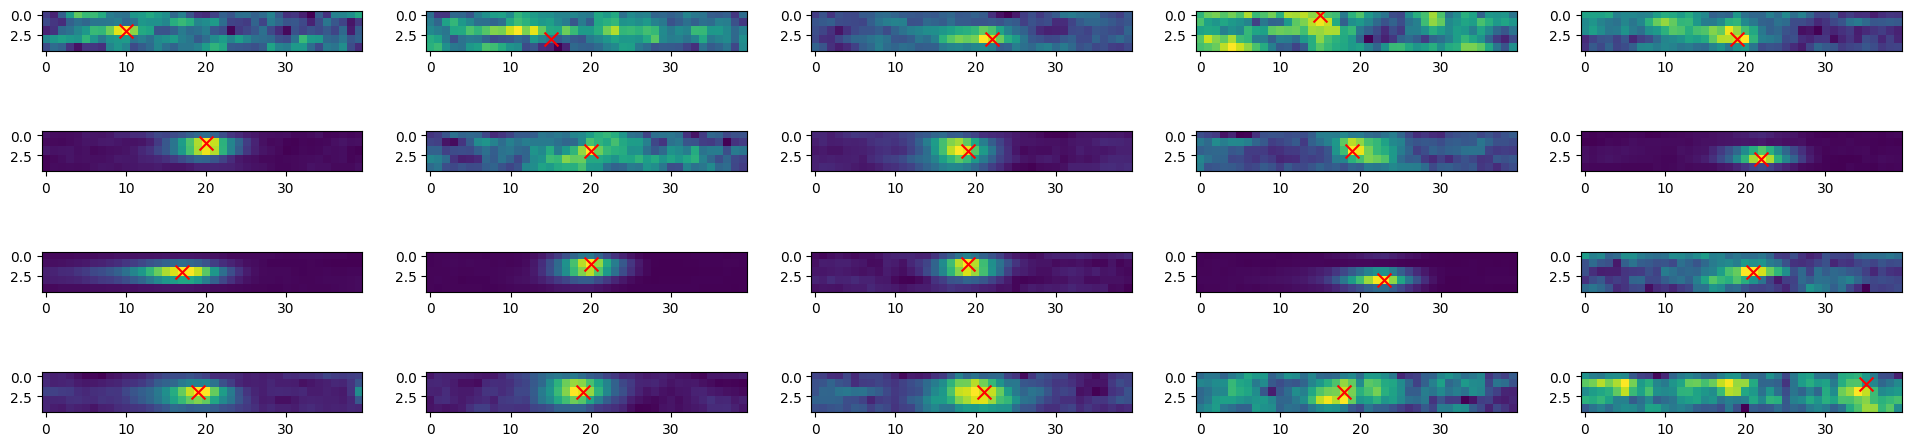

In [9]:
import matplotlib.pyplot as plt
visualize = True
id_ = 7

# Extracting and plotting DDMs
raw_counts = fit_data
raw_counts = np.array(raw_counts)
print(raw_counts.shape)
print('Min:', np.nanmin(raw_counts))
print('Max:', np.nanmax(raw_counts))
print('NaNs:', np.count_nonzero(np.isnan(raw_counts)), '({:.2f}%)'.format(np.count_nonzero(np.isnan(raw_counts))/raw_counts.size*100))
plt.figure(figsize=(24,6))
if visualize:

    for ddm in range(20):

        plt.subplot(4, 5, ddm+1)
        
        plt.imshow(raw_counts[ddm].reshape(40, 5).T,  cmap='viridis')
        sp_center = sp_centers[ddm]
        plt.scatter(sp_center[0], sp_center[1], color='red', marker='x', s=100)
        
    plt.show()

In [10]:
pd.DataFrame(fit_data).describe()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
count,3662580.0,3662580.0,3.662580e+06,3.662580e+06,3662580.0,3662580.0,3662580.0,3.662580e+06,3.662580e+06,3662580.0,...,3.662580e+06,3.662580e+06,3.662580e+06,3.662580e+06,3662580.0,3.662580e+06,3.662580e+06,3.662580e+06,3.662580e+06,3.662580e+06
mean,69059592.0,70148504.0,7.148142e+07,7.097925e+07,69326296.0,69815464.0,71064776.0,7.277956e+07,7.214342e+07,70125456.0,...,6.282206e+07,6.376827e+07,6.463993e+07,6.366053e+07,62805016.0,6.281104e+07,6.373952e+07,6.459832e+07,6.362894e+07,6.278998e+07
std,16682243.0,17068330.0,2.137706e+07,1.938508e+07,16696539.0,18362114.0,19200756.0,2.612414e+07,2.286242e+07,18467794.0,...,6.741786e+06,1.743151e+07,2.594707e+07,1.229607e+07,6518797.0,6.737195e+06,1.719058e+07,2.559535e+07,1.223081e+07,6.506334e+06
min,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,60814391.0,61244935.0,6.153235e+07,6.137930e+07,60911708.0,60896204.0,61349663.0,6.165218e+07,6.148865e+07,60994596.0,...,5.916373e+07,5.930998e+07,5.938674e+07,5.931395e+07,59151943.0,5.915826e+07,5.929740e+07,5.937293e+07,5.929668e+07,5.914343e+07
50%,64362392.0,65106346.0,6.566210e+07,6.540545e+07,64562696.0,64510402.0,65299962.0,6.590457e+07,6.562224e+07,64724916.0,...,6.222877e+07,6.242836e+07,6.254970e+07,6.245099e+07,62223362.0,6.221348e+07,6.240914e+07,6.251876e+07,6.242816e+07,6.221167e+07
75%,71269450.0,72938328.0,7.419637e+07,7.360867e+07,71734242.0,71749050.0,73566504.0,7.499004e+07,7.432456e+07,72235960.0,...,6.578570e+07,6.615093e+07,6.639362e+07,6.620250e+07,65776777.0,6.577033e+07,6.612967e+07,6.635201e+07,6.617070e+07,6.576447e+07
max,408546336.0,576744960.0,1.294292e+09,1.299175e+09,584521216.0,425508096.0,604924608.0,1.166525e+09,1.198319e+09,565676096.0,...,1.069963e+09,3.489875e+09,3.510953e+09,1.233723e+09,968157568.0,1.024526e+09,3.353706e+09,3.435377e+09,1.452134e+09,1.067369e+09


In [11]:
# Select a random subset of 2 million samples
num_samples = 1000000
indices = np.random.choice(fit_data.shape[0], size=num_samples, replace=False)
fit_data = fit_data[indices]
labels = labels[indices]
sp_centers = sp_centers[indices]

In [12]:
fit_data.shape, labels.shape, #sp_centers.shape

((1000000, 200), (1000000,))

In [13]:
# Versione modificata della funzione helper
def extract_ddm_features_row(row, sp_center, extractor):
    """Helper function for parallel processing"""
    return extractor.extract_ddm_features(
        fit_data=row,
        quadrants=True,
        include_peak_features=True,
        sp_center=None  
    )

peak_detector = PeakRegionDetector(N=40, method='adaptive')
# Example usage modificato:
features_extractor = DDMFeatureExtractorV2(data_format='40x5', peak_detector=peak_detector)

# Versione con zip per passare entrambi gli elementi
combined_features = Parallel(n_jobs=8, backend="loky")(
    delayed(extract_ddm_features_row)(row, sp_center, features_extractor)
    for row, sp_center in tqdm(zip(fit_data, sp_centers), desc="Features extraction", total=len(fit_data))
)

Features extraction: 100%|██████████| 1000000/1000000 [52:51<00:00, 315.28it/s]


In [14]:
FEATURES = list(combined_features[0].keys())

In [15]:
FEATURES

['global_mean',
 'global_std',
 'global_min',
 'global_max',
 'global_median',
 'global_range',
 'global_skew',
 'global_kurtosis',
 'global_entropy',
 'global_gini',
 'peak_index',
 'peak_value',
 'global_center_of_mass',
 'global_inertia',
 'sum_third_1',
 'mean_third_1',
 'max_third_1',
 'sum_third_2',
 'mean_third_2',
 'max_third_2',
 'sum_third_3',
 'mean_third_3',
 'max_third_3',
 'mean_w1',
 'std_w1',
 'max_w1',
 'mean_w2',
 'std_w2',
 'max_w2',
 'mean_w3',
 'std_w3',
 'max_w3',
 'mean_w4',
 'std_w4',
 'max_w4',
 'mean_w5',
 'std_w5',
 'max_w5',
 'global_mean_diff',
 'global_std_diff',
 'global_max_diff',
 'global_min_diff',
 'global_n_positive_diff',
 'global_n_negative_diff',
 'global_n_zero_diff',
 'autocorr_lag1',
 'autocorr_lag2',
 'autocorr_lag3',
 'global_fft_peak_freq',
 'global_fft_max',
 'global_fft_median',
 'global_fft_mean',
 'global_percentile_25',
 'global_percentile_75',
 'global_percentile_90',
 'global_percentile_10',
 'global_energy',
 'global_power',
 'global

In [16]:
# Convert to numpy array if needed
# First convert dict features to arrays
if combined_features:
    feature_names = list(combined_features[0].keys())
    feature_arrays = {name: np.array([f[name] for f in combined_features]) 
                     for name in feature_names}
    combined_features_array = np.column_stack([feature_arrays[name] for name in feature_names])
    print(f"Combined features shape: {combined_features_array.shape}")


Combined features shape: (1000000, 143)


In [17]:
"""flat_features = [row[0] if isinstance(row, list) and len(row) > 0 else row for row in combined_features]

del combined_features

combined_features = np.array([[row[key] for key in FEATURES] for row in flat_features])
del flat_features
combined_features.shape"""

# Check for NaN and infinite values
mask_finite = np.all(np.isfinite(combined_features_array), axis=1) & (np.abs(combined_features_array) < np.finfo(np.float64).max).all(axis=1)

fit_data_with_features_clean = combined_features_array[mask_finite]
labels_clean = labels[mask_finite]
del labels, fit_data

In [18]:
fit_data_with_features_clean.shape, labels_clean.shape

((1000000, 143), (1000000,))

In [19]:
pd.DataFrame(fit_data_with_features_clean).describe()

,0,1,2,3,4,5,6,7,8,9,...,133,134,135,136,137,138,139,140,141,142
count,1.000000e+06,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1.000000e+06,1.000000e+06
mean,5.000000e-03,0.002029,3.296742e-03,0.013783,0.004227,0.010486,1.580448,3.613240,5.178543,0.179507,...,1.264684e-02,2.433353e-03,4.445715e-03,0.001299,9.193830e-03,9.770857e-04,4.803096e-03,0.001976,1.246773e-02,1.967535e-03
std,3.567413e-18,0.002113,1.114531e-03,0.010050,0.000964,0.011040,1.060929,3.849180,0.191298,0.174459,...,9.189551e-03,1.622541e-03,7.939940e-04,0.001531,5.904453e-03,4.488770e-04,8.302075e-04,0.002264,9.268760e-03,1.403154e-03
min,5.000000e-03,0.000096,1.434119e-20,0.005213,0.000830,0.000496,-1.360913,-1.995862,4.166318,0.010778,...,1.434119e-20,1.234019e-38,1.480723e-20,0.000000,1.480723e-20,8.770166e-39,1.480723e-20,0.000000,1.480723e-20,1.315525e-38
25%,5.000000e-03,0.000459,2.643004e-03,0.006376,0.003767,0.002402,0.575408,0.339530,5.149302,0.050416,...,6.004041e-03,1.523278e-03,4.163577e-03,0.000314,5.513370e-03,8.213507e-04,4.565622e-03,0.000401,5.918215e-03,1.417607e-03
50%,5.000000e-03,0.001063,3.620958e-03,0.009277,0.004682,0.005626,1.699432,2.606032,5.277993,0.101703,...,8.414932e-03,1.705881e-03,4.726378e-03,0.000600,6.445905e-03,9.516365e-04,4.935155e-03,0.000932,8.237623e-03,1.527594e-03
75%,5.000000e-03,0.003122,4.157651e-03,0.018398,0.004957,0.015723,2.378713,5.828240,5.294143,0.273354,...,1.645548e-02,2.508849e-03,4.967360e-03,0.001758,1.073563e-02,1.023965e-03,5.099564e-03,0.002964,1.630539e-02,1.860005e-03
max,5.000000e-03,0.011526,4.776928e-03,0.086437,0.005361,0.084644,7.220591,61.590269,5.298134,0.724511,...,6.885997e-02,2.561864e-02,1.350382e-02,0.017838,8.214819e-02,1.780761e-02,1.167298e-02,0.019762,8.643705e-02,3.071394e-02


In [20]:
# Saving features and labels
save = True
if save:
    os.makedirs('processed_data/binary_classification/data_w_features', exist_ok=True)
    pd.DataFrame(fit_data_with_features_clean, columns=FEATURES).to_parquet('processed_data/binary_classification/data_w_features/combined_features_q_peak_enh.parquet', index=False)
    pd.DataFrame(labels_clean).to_parquet('processed_data/binary_classification/data_w_features/labels_binary_q_peak_enh.parquet', index=False)

In [21]:
fit_data_with_features_df = pd.DataFrame(fit_data_with_features_clean, columns=FEATURES)
labels_clean_df = pd.DataFrame(labels_clean, columns=['0'])
del fit_data_with_features_clean
fit_data_with_features_df.head()

,global_mean,global_std,global_min,global_max,global_median,global_range,global_skew,global_kurtosis,global_entropy,global_gini,...,ddm_q2_max,ddm_q2_energy,ddm_q3_mean,ddm_q3_std,ddm_q3_max,ddm_q3_energy,ddm_q4_mean,ddm_q4_std,ddm_q4_max,ddm_q4_energy
0,0.005,0.000766,0.004162,0.007808,0.004765,0.003646,1.544033,2.125641,5.287330,0.078572,...,0.007802,0.001697,0.004683,0.000695,0.007031,0.000897,0.004879,0.000837,0.007808,0.001470
1,0.005,0.002797,0.002804,0.018606,0.003863,0.015802,2.567944,6.668886,5.180410,0.235962,...,0.018606,0.002617,0.004428,0.001650,0.011330,0.000893,0.004817,0.002919,0.017549,0.001904
2,0.005,0.000990,0.003987,0.008469,0.004626,0.004482,1.582542,1.896351,5.280282,0.099705,...,0.008178,0.001637,0.004923,0.001001,0.007759,0.001010,0.004860,0.001184,0.008469,0.001501
3,0.005,0.006145,0.001060,0.029992,0.002015,0.028933,2.274335,4.746135,4.774962,0.534031,...,0.029992,0.006808,0.002615,0.002703,0.014397,0.000566,0.004749,0.006561,0.028599,0.003936
4,0.005,0.000237,0.004504,0.005701,0.004987,0.001198,0.311616,-0.361758,5.297200,0.026885,...,0.005538,0.001537,0.004920,0.000185,0.005383,0.000970,0.004968,0.000308,0.005701,0.001486
